In [1]:
import warnings
warnings.simplefilter(action='ignore')
warnings.filterwarnings('ignore')

from collections import Counter

# import the necessary package
import pandas as pd
import numpy as np

# data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Algorithms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score ,train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

from sklearn.metrics import classification_report,confusion_matrix, mean_squared_error,precision_score, f1_score,accuracy_score

In [2]:
data = pd.read_csv('maternal_health_asha_india.csv')

In [3]:
data

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,Haemoglobin,GestationalAge,Parity,Oedema,PreviousComplications,DistanceToHospital,WeightGain
0,25,130,80,15.0,98.0,86,high risk,9.7,42,0,1,1,11.8,3.7
1,35,140,90,13.0,98.0,70,high risk,8.6,37,2,1,1,26.5,4.8
2,29,90,70,8.0,100.0,80,high risk,10.0,30,1,1,0,32.2,5.4
3,30,140,85,7.0,98.0,70,high risk,11.5,31,3,1,0,47.5,2.7
4,35,120,60,6.1,98.0,76,low risk,11.2,26,2,0,0,5.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk,7.8,25,2,1,0,46.0,2.8
1010,55,120,90,18.0,98.0,60,high risk,11.2,11,1,1,1,15.6,3.9
1011,35,85,60,19.0,98.0,86,high risk,9.2,36,2,1,0,20.8,3.3
1012,43,120,90,18.0,98.0,70,high risk,12.5,42,1,1,1,9.5,4.0


In [4]:

#Age	             Advanced maternal age (>35) high risk
#SystolicBP	         Hypertension indicator
#DiastolicBP	     Preeclampsia risk
#BS	                 Gestational diabetes indicator
#BodyTemp	         Infection/Fever
#HeartRate	         Maternal stress/cardiac risk
#Haemoglobin	         Anemia detection
#GestationalAge	            Pregnancy stage
#Oedema	                     Pregnancy complications
#PreviousComplications	      Strong predictor
#WeightGain	                    Nutritional health

In [5]:
data['PulsePressure'] = data['SystolicBP'] - data['DiastolicBP']

In [6]:
data['MAP'] = (data['SystolicBP'] + 2*data['DiastolicBP']) / 3

In [7]:
data['Hypertension'] = (
    (data['SystolicBP'] >= 140) |
    (data['DiastolicBP'] >= 90)
).astype(int)

In [8]:
data['Anemia'] = (data['Haemoglobin'] < 11).astype(int)

In [9]:
data['Diabetes'] = (data['BS'] >= 7.8).astype(int)

In [10]:
data['AdvancedAge'] = (data['Age'] >= 35).astype(int)

In [11]:
def trimester(x):
    if x <= 12:
        return 1
    elif x <= 27:
        return 2
    else:
        return 3

data['Trimester'] = data['GestationalAge'].apply(trimester)

In [12]:
data['RiskScore'] = (
    data['Hypertension'] +
    data['Anemia'] +
    data['Diabetes'] +
    data['Oedema'] +
    data['PreviousComplications']
)

In [13]:
data['FarHospital'] = (
    data['DistanceToHospital'] > 20
).astype(int)

In [14]:
data['LowWeightGain'] = (
    data['WeightGain'] < 5
).astype(int)

In [15]:
data['Age_BP'] = (data['Age'] *data['MAP'])

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1014 non-null   int64  
 1   SystolicBP             1014 non-null   int64  
 2   DiastolicBP            1014 non-null   int64  
 3   BS                     1014 non-null   float64
 4   BodyTemp               1014 non-null   float64
 5   HeartRate              1014 non-null   int64  
 6   RiskLevel              1014 non-null   object 
 7   Haemoglobin            1014 non-null   float64
 8   GestationalAge         1014 non-null   int64  
 9   Parity                 1014 non-null   int64  
 10  Oedema                 1014 non-null   int64  
 11  PreviousComplications  1014 non-null   int64  
 12  DistanceToHospital     1014 non-null   float64
 13  WeightGain             1014 non-null   float64
 14  PulsePressure          1014 non-null   int64  
 15  MAP 

In [17]:
data['DM_HTN'] = (
    data['Diabetes'] *
    data['Hypertension']
)

In [18]:
data['Anemia_GA'] = (
    data['Anemia'] *
    data['GestationalAge']
)

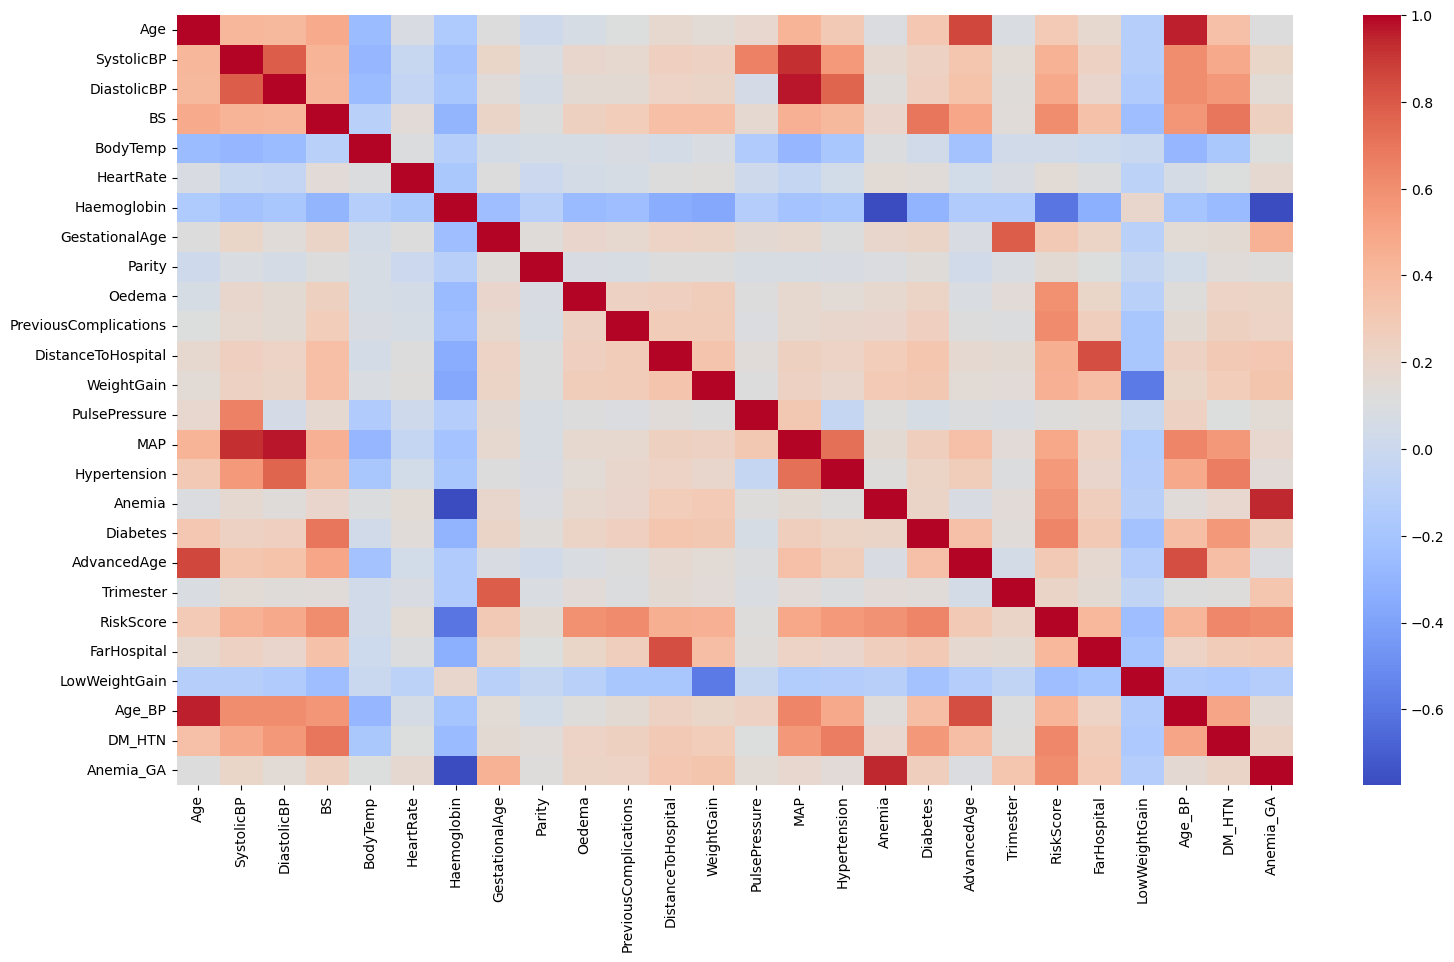

In [19]:
plt.figure(figsize=(18,10))
sns.heatmap(data.corr(numeric_only=True),
            annot=False,
            cmap='coolwarm')
plt.show()

In [20]:
data.drop(columns=['Hypertension','Anemia','Diabetes','AdvancedAge','Trimester','Age_BP','DM_HTN','Anemia_GA','Haemoglobin','LowWeightGain','Oedema','FarHospital'],inplace=True)

In [21]:
data.columns

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel', 'GestationalAge', 'Parity', 'PreviousComplications',
       'DistanceToHospital', 'WeightGain', 'PulsePressure', 'MAP',
       'RiskScore'],
      dtype='object')

In [22]:
data['RiskLevel'].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [23]:
data.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,GestationalAge,Parity,PreviousComplications,DistanceToHospital,WeightGain,PulsePressure,MAP,RiskScore
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775,31.244576,1.420118,0.271203,14.997140,2.416765,36.737673,88.706443,1.821499
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702,6.916463,0.991090,0.444800,11.262706,1.472363,11.369944,14.584820,1.393360
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000,10.000000,0.000000,0.000000,1.000000,0.000000,8.000000,56.666667,0.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000,26.000000,1.000000,0.000000,6.800000,1.400000,30.000000,76.666667,1.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000,31.000000,1.000000,0.000000,12.000000,2.200000,35.000000,93.333333,2.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000,37.000000,2.000000,1.000000,21.575000,3.400000,40.000000,100.000000,3.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000,42.000000,3.000000,1.000000,59.200000,7.900000,75.000000,120.000000,5.000000


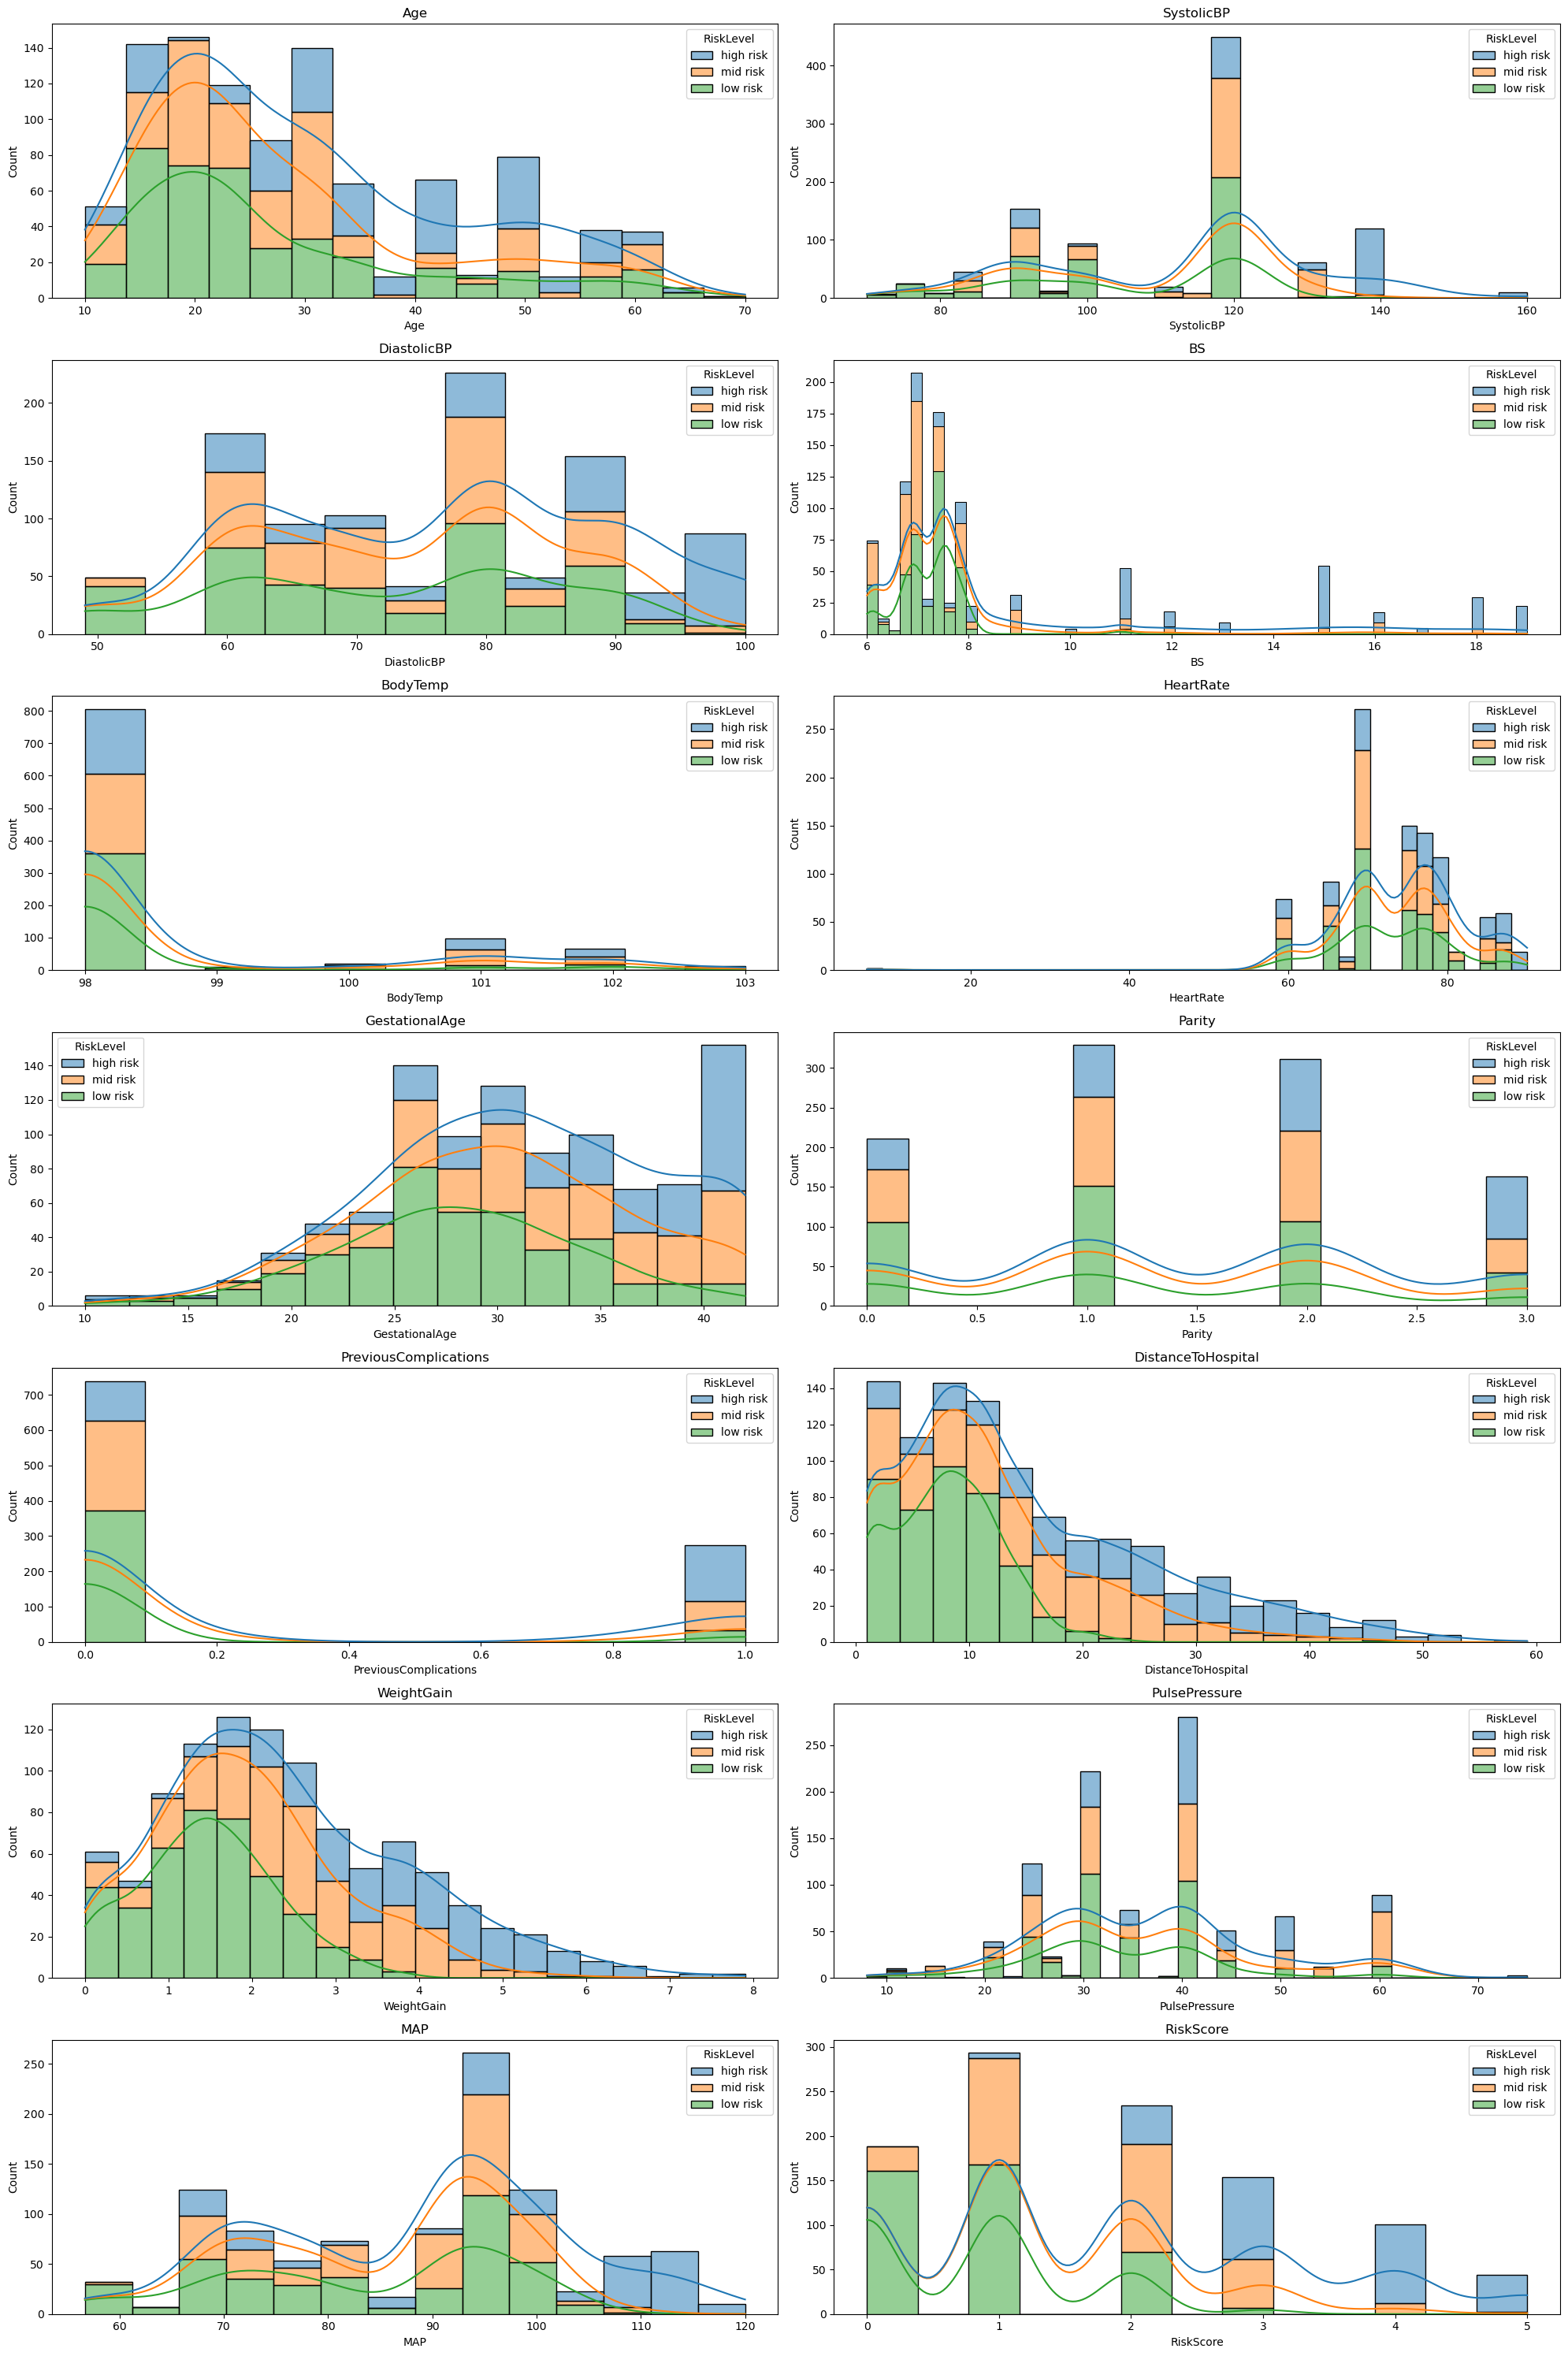

In [24]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(20,30))
risk_level_order = ['high risk', 'mid risk', 'low risk']

for ax, column in zip(axes.flatten(), data.columns.drop('RiskLevel')):
    sns.histplot(data=data,x=column,kde=True,hue='RiskLevel',hue_order=risk_level_order,multiple='stack',ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

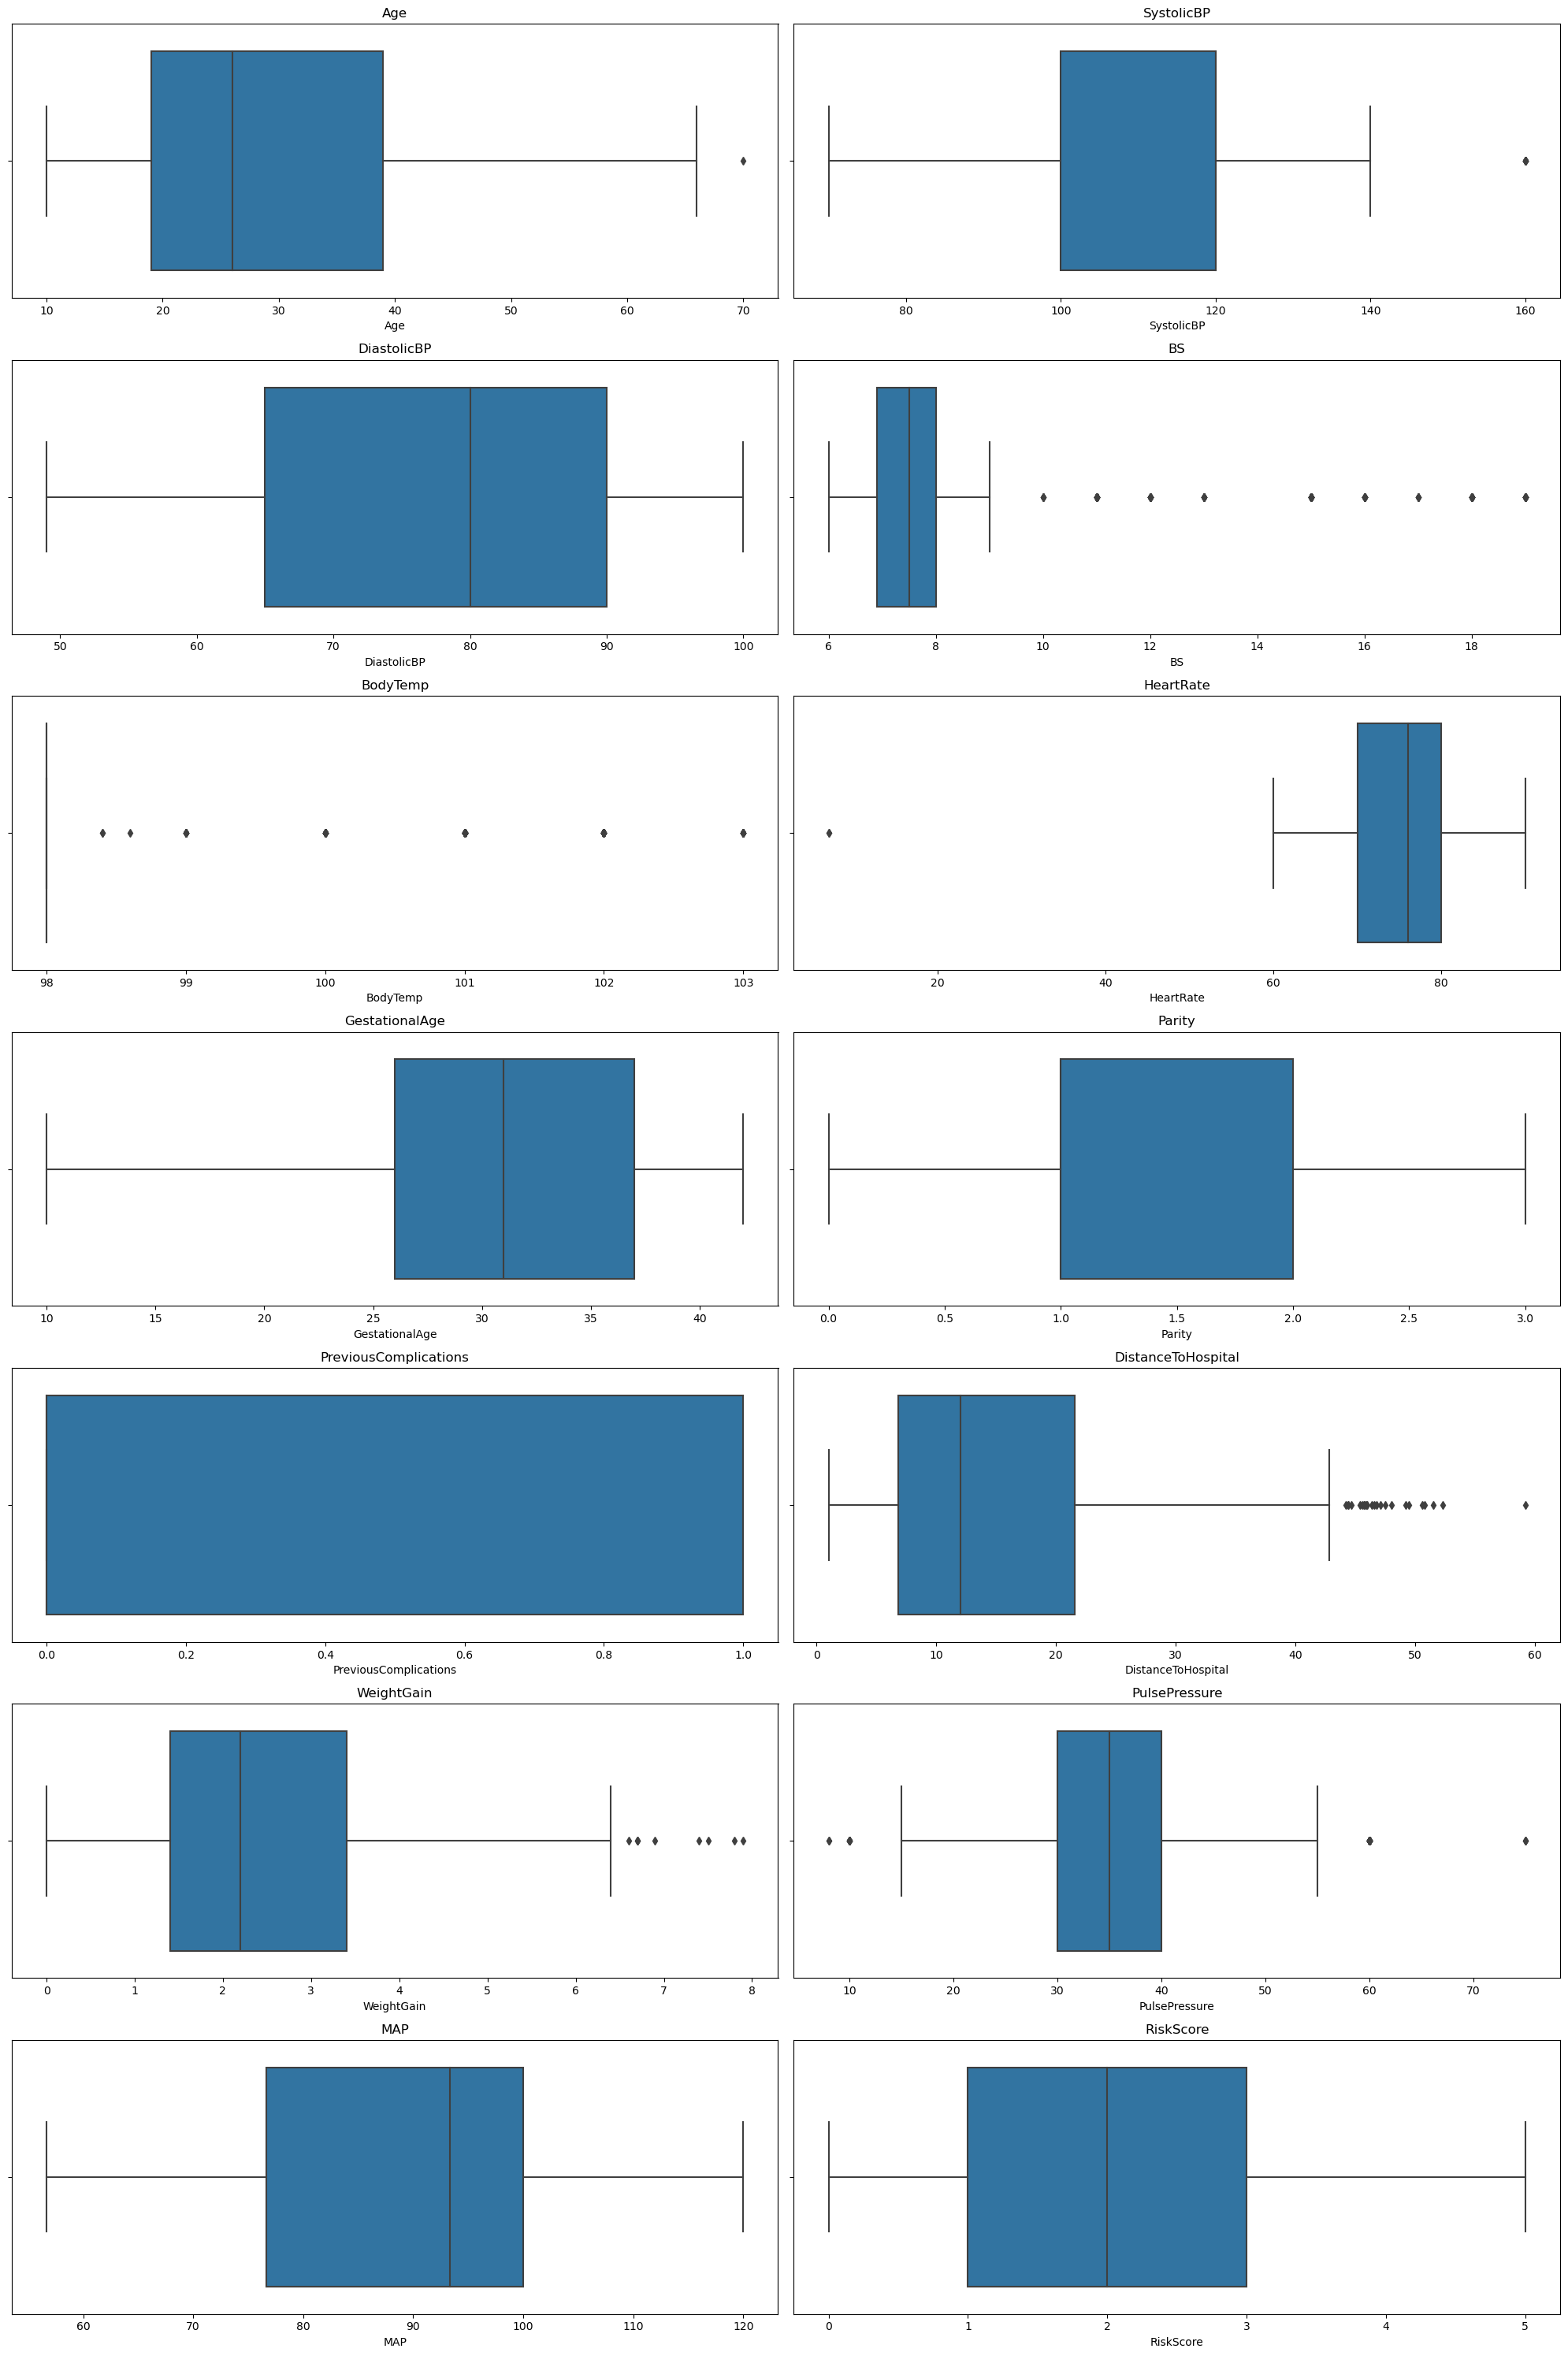

In [25]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(20,30))

for ax, column in zip(axes.flatten(), data.columns.drop('RiskLevel')):
    sns.boxplot(data=data,x=data[column],ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

In [26]:
data.head(5)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,GestationalAge,Parity,PreviousComplications,DistanceToHospital,WeightGain,PulsePressure,MAP,RiskScore
0,25,130,80,15.0,98.0,86,high risk,42,0,1,11.8,3.7,50,96.666667,4
1,35,140,90,13.0,98.0,70,high risk,37,2,1,26.5,4.8,50,106.666667,5
2,29,90,70,8.0,100.0,80,high risk,30,1,0,32.2,5.4,20,76.666667,3
3,30,140,85,7.0,98.0,70,high risk,31,3,0,47.5,2.7,55,103.333333,2
4,35,120,60,6.1,98.0,76,low risk,26,2,0,5.5,0.0,60,80.000000,0


In [27]:
data

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,GestationalAge,Parity,PreviousComplications,DistanceToHospital,WeightGain,PulsePressure,MAP,RiskScore
0,25,130,80,15.0,98.0,86,high risk,42,0,1,11.8,3.7,50,96.666667,4
1,35,140,90,13.0,98.0,70,high risk,37,2,1,26.5,4.8,50,106.666667,5
2,29,90,70,8.0,100.0,80,high risk,30,1,0,32.2,5.4,20,76.666667,3
3,30,140,85,7.0,98.0,70,high risk,31,3,0,47.5,2.7,55,103.333333,2
4,35,120,60,6.1,98.0,76,low risk,26,2,0,5.5,0.0,60,80.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk,25,2,0,46.0,2.8,60,80.000000,3
1010,55,120,90,18.0,98.0,60,high risk,11,1,1,15.6,3.9,30,100.000000,4
1011,35,85,60,19.0,98.0,86,high risk,36,2,0,20.8,3.3,25,68.333333,3
1012,43,120,90,18.0,98.0,70,high risk,42,1,1,9.5,4.0,30,100.000000,4


In [28]:
for column in data.columns:
    print(data[column].value_counts())
    print("*"*20)

Age
23    71
19    67
17    63
15    60
35    50
25    48
32    48
22    45
50    43
29    40
21    38
40    37
55    37
12    35
60    34
30    30
28    28
48    26
42    23
20    22
31    22
18    19
16    16
54    12
13    12
27     9
49     9
45     9
37     6
33     5
34     5
43     5
10     4
36     4
39     4
24     3
65     3
44     3
14     3
26     3
63     2
38     2
59     2
62     1
51     1
66     1
56     1
70     1
41     1
46     1
Name: count, dtype: int64
********************
SystolicBP
120    449
90     154
140    120
100     92
130     60
85      43
110     19
76      16
95      12
160     10
75       8
115      8
70       7
80       5
135      3
78       3
83       2
99       2
129      1
Name: count, dtype: int64
********************
DiastolicBP
80     226
60     174
90     153
70     100
100     87
65      87
85      49
75      38
95      36
49      25
50      24
63       8
76       3
68       2
89       1
69       1
Name: count, dtype: int64
******************

In [29]:
data[(data['Age'] < 18)]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,GestationalAge,Parity,PreviousComplications,DistanceToHospital,WeightGain,PulsePressure,MAP,RiskScore
15,15,120,80,7.01,98.0,70,low risk,22,0,0,17.2,2.8,40,93.333333,1
19,10,70,50,6.90,98.0,70,low risk,32,1,0,2.2,2.4,20,56.666667,1
25,16,100,70,7.20,98.0,80,low risk,34,0,0,14.4,2.1,30,80.000000,0
35,12,95,60,6.10,102.0,60,low risk,36,2,0,9.4,0.5,35,71.666667,1
48,15,76,49,7.50,98.0,77,low risk,35,2,0,12.3,1.3,27,58.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,12,90,60,8.00,102.0,66,high risk,22,1,1,12.2,2.0,30,70.000000,2
1000,12,90,60,11.00,102.0,60,high risk,42,2,1,4.8,3.2,30,70.000000,3
1004,13,90,65,9.00,101.0,80,high risk,40,3,0,18.4,2.0,25,73.333333,2
1005,17,90,65,7.70,103.0,67,high risk,25,1,1,26.7,5.0,25,73.333333,2


In [30]:
data[(data['Age'] < 18) & (data['RiskLevel']=='high risk')]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,GestationalAge,Parity,PreviousComplications,DistanceToHospital,WeightGain,PulsePressure,MAP,RiskScore
145,14,90,65,7.0,101.0,70,high risk,32,2,0,27.9,4.1,25,73.333333,2
152,17,110,75,12.0,101.0,76,high risk,42,3,0,31.3,5.4,35,86.666667,3
171,12,90,60,7.9,102.0,66,high risk,42,3,1,1.0,5.1,30,70.000000,3
191,17,90,65,6.1,103.0,67,high risk,35,1,1,6.7,3.9,25,73.333333,3
199,17,85,60,9.0,102.0,86,high risk,42,1,1,49.2,2.8,25,68.333333,4
237,17,90,60,11.0,101.0,78,high risk,42,1,1,14.5,2.7,30,70.000000,4
238,17,90,63,8.0,101.0,70,high risk,19,1,0,9.4,3.6,27,72.000000,2
240,17,120,80,7.0,102.0,76,high risk,42,3,0,13.1,3.8,40,93.333333,2
248,17,110,75,13.0,101.0,76,high risk,39,1,1,22.1,2.6,35,86.666667,2
267,12,90,60,8.0,102.0,66,high risk,34,3,1,30.4,3.5,30,70.000000,3


In [31]:
print(data['Age'].min())
print(data['Age'].max())

10
70


In [32]:
data[(data['Age'] < 15)& (data['Parity']==1)]

# Yes, a 10-year-old girl can become pregnant, but it is extremely rare and carries serious medical and psychological risks.

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,GestationalAge,Parity,PreviousComplications,DistanceToHospital,WeightGain,PulsePressure,MAP,RiskScore
19,10,70,50,6.9,98.0,70,low risk,32,1,0,2.2,2.4,20,56.666667,1
62,12,95,60,7.2,98.0,77,low risk,19,1,0,11.3,2.1,35,71.666667,1
180,12,95,60,6.1,102.0,60,low risk,18,1,0,4.7,2.1,35,71.666667,0
189,13,90,65,7.9,101.0,80,mid risk,36,1,0,1.0,3.6,25,73.333333,3
244,12,95,60,7.2,98.0,77,low risk,24,1,0,7.6,1.2,35,71.666667,1
344,12,95,60,6.9,98.0,77,low risk,19,1,0,6.7,2.4,35,71.666667,1
401,12,120,95,7.8,98.0,60,low risk,34,1,0,5.4,2.5,25,103.333333,3
552,12,90,60,7.5,102.0,60,low risk,28,1,0,12.0,1.7,30,70.000000,0
717,13,90,65,7.9,101.0,80,mid risk,30,1,0,15.2,1.0,25,73.333333,2
763,12,95,60,6.9,98.0,65,mid risk,32,1,0,15.6,4.8,35,71.666667,1


In [33]:
data[(data['Age'] < 15)& (data['Parity']==2)]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,GestationalAge,Parity,PreviousComplications,DistanceToHospital,WeightGain,PulsePressure,MAP,RiskScore
35,12,95,60,6.1,102.0,60,low risk,36,2,0,9.4,0.5,35,71.666667,1
82,12,95,60,6.9,98.0,65,mid risk,33,2,0,14.5,4.0,35,71.666667,1
145,14,90,65,7.0,101.0,70,high risk,32,2,0,27.9,4.1,25,73.333333,2
306,12,120,95,6.9,98.0,60,low risk,28,2,1,6.8,2.0,25,103.333333,2
351,12,95,60,6.9,98.0,65,mid risk,31,2,0,1.0,4.2,35,71.666667,1
380,13,90,65,7.8,101.0,80,mid risk,29,2,0,15.8,2.9,25,73.333333,3
418,12,120,90,6.8,98.0,80,mid risk,38,2,0,14.2,1.5,30,100.000000,1
543,12,90,60,7.5,102.0,66,low risk,23,2,0,20.0,1.1,30,70.000000,0
561,13,90,65,7.5,101.0,80,low risk,28,2,0,10.4,1.8,25,73.333333,0
670,10,100,50,6.0,99.0,70,mid risk,24,2,0,31.7,2.9,50,66.666667,0


In [34]:
data[(data['Age'] < 15)& (data['Parity']==3)]


# Records exhibiting clinically implausible combinations (e.g., maternal age below 15 years with parity ≥3) 
# were identified as domain-specific anomalies and removed during data cleaning.

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,GestationalAge,Parity,PreviousComplications,DistanceToHospital,WeightGain,PulsePressure,MAP,RiskScore
148,12,95,60,6.7,98.0,77,low risk,20,3,0,8.0,2.2,35,71.666667,0
171,12,90,60,7.9,102.0,66,high risk,42,3,1,1.0,5.1,30,70.000000,3
250,10,85,65,6.9,98.0,70,low risk,29,3,0,10.6,1.6,20,71.666667,1
267,12,90,60,8.0,102.0,66,high risk,34,3,1,30.4,3.5,30,70.000000,3
276,12,90,60,11.0,102.0,60,high risk,38,3,1,25.4,4.7,30,70.000000,4
285,13,90,65,9.0,101.0,80,high risk,38,3,0,24.3,4.4,25,73.333333,2
371,12,90,60,7.8,102.0,60,high risk,37,3,1,11.9,3.6,30,70.000000,4
610,13,90,65,7.5,101.0,80,high risk,42,3,1,35.6,4.7,25,73.333333,3
673,12,100,50,6.4,98.0,70,mid risk,33,3,0,23.2,2.5,50,66.666667,1
940,12,90,60,7.5,102.0,60,low risk,24,3,0,14.8,1.8,30,70.000000,1


In [35]:
len(data[(data['Age'] < 15) & (data['Parity'] >= 3)])

11

In [36]:
len(data[(data['Age'] < 15) & (data['Parity'] >= 2)])

# Age 14 + parity 2 theoretically possible hai, although very rare.

28

In [37]:
len(data[(data['Age'] < 13) & (data['Parity'] >= 2)])

20

In [38]:
len(data[(data['Age'] < 15) & (data['Parity'] >= 1)])

44

In [39]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1009    False
1010    False
1011    False
1012    False
1013    False
Length: 1014, dtype: bool

In [40]:
data.drop(data[(data['Age'] < 15) & (data['Parity'] >= 3)].index,inplace=True)


In [41]:
data.drop(data[(data['Age'] < 13) & (data['Parity'] >= 2)].index,inplace=True)

In [42]:
data

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,GestationalAge,Parity,PreviousComplications,DistanceToHospital,WeightGain,PulsePressure,MAP,RiskScore
0,25,130,80,15.0,98.0,86,high risk,42,0,1,11.8,3.7,50,96.666667,4
1,35,140,90,13.0,98.0,70,high risk,37,2,1,26.5,4.8,50,106.666667,5
2,29,90,70,8.0,100.0,80,high risk,30,1,0,32.2,5.4,20,76.666667,3
3,30,140,85,7.0,98.0,70,high risk,31,3,0,47.5,2.7,55,103.333333,2
4,35,120,60,6.1,98.0,76,low risk,26,2,0,5.5,0.0,60,80.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk,25,2,0,46.0,2.8,60,80.000000,3
1010,55,120,90,18.0,98.0,60,high risk,11,1,1,15.6,3.9,30,100.000000,4
1011,35,85,60,19.0,98.0,86,high risk,36,2,0,20.8,3.3,25,68.333333,3
1012,43,120,90,18.0,98.0,70,high risk,42,1,1,9.5,4.0,30,100.000000,4


In [43]:
data['RiskLevel'].value_counts(normalize=True)*100

RiskLevel
low risk     40.363269
mid risk     33.097881
high risk    26.538850
Name: proportion, dtype: float64

In [44]:
le = LabelEncoder()
data['RiskLevel'] = le.fit_transform(data['RiskLevel'])

In [45]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'high risk': 0, 'low risk': 1, 'mid risk': 2}


In [46]:
x = data.drop(['RiskLevel'], axis=1)
y = data['RiskLevel']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [48]:
# for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.fit_transform(x)

# Random Forest 

In [49]:
print(X_train.shape, X_test.shape)

(792, 14) (199, 14)


In [50]:
rf = RandomForestClassifier( n_estimators=500,max_depth=10,min_samples_split=5,min_samples_leaf=2,random_state=42)

In [51]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [52]:
y_pred_rf = rf.predict(X_test)

In [53]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.864321608040201

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        43
           1       0.86      0.94      0.90        87
           2       0.85      0.74      0.79        69

    accuracy                           0.86       199
   macro avg       0.87      0.86      0.86       199
weighted avg       0.86      0.86      0.86       199


Confusion Matrix
[[39  0  4]
 [ 0 82  5]
 [ 5 13 51]]


                  Feature  Importance
9      DistanceToHospital    0.165201
13              RiskScore    0.164791
10             WeightGain    0.156499
3                      BS    0.120735
1              SystolicBP    0.079515
12                    MAP    0.058566
6          GestationalAge    0.053510
0                     Age    0.040896
4                BodyTemp    0.035353
11          PulsePressure    0.034908
2             DiastolicBP    0.029279
5               HeartRate    0.026654
8   PreviousComplications    0.018909
7                  Parity    0.015184


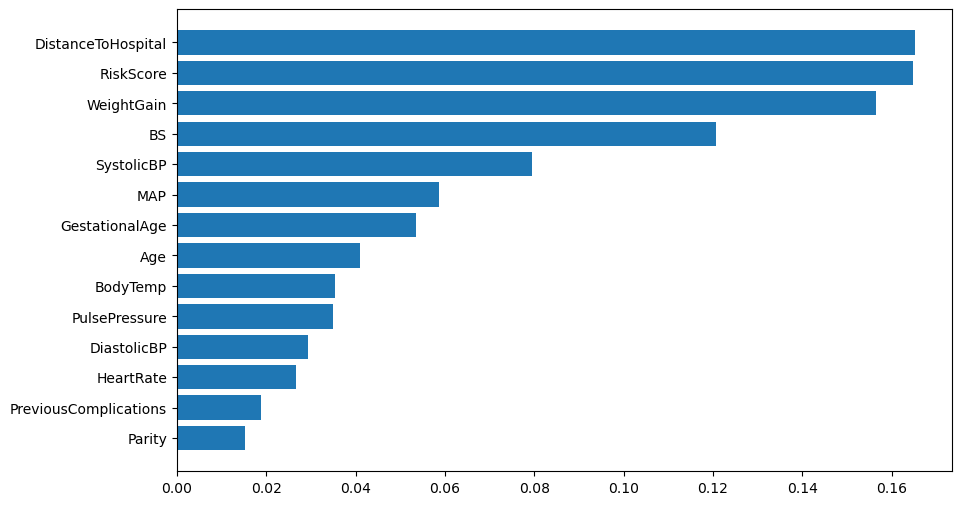

In [54]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'][:15],
    importance['Importance'][:15]
)
plt.gca().invert_yaxis()
plt.show()

In [55]:
data.groupby('RiskLevel')['DistanceToHospital'].mean()

# high-risk pregnancies were associated with significantly greater average distance to healthcare facilities (24.77 km) 
# compared to low-risk pregnancies (7.97 km),suggesting that accessibility to healthcare services may influence maternal 
# health outcomes.

RiskLevel
0    24.770722
1     7.966250
2    15.578963
Name: DistanceToHospital, dtype: float64

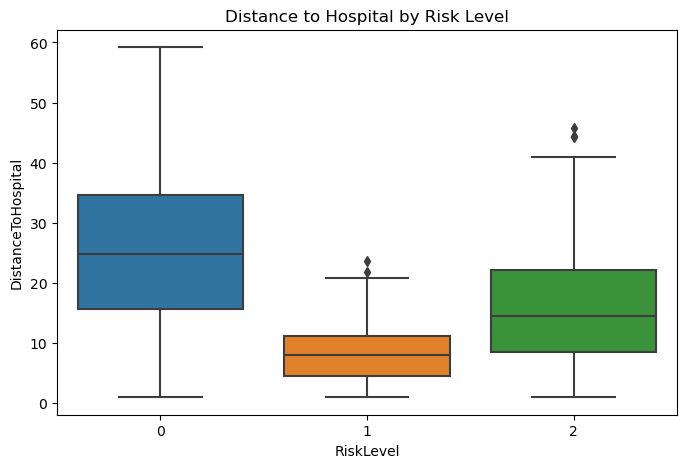

In [56]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=data,
    x='RiskLevel',
    y='DistanceToHospital'
)

plt.title("Distance to Hospital by Risk Level")
plt.show()

In [57]:
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy :", rf.score(X_test, y_test))

Train Accuracy: 0.9722222222222222
Test Accuracy : 0.864321608040201


In [58]:
X2 = x.drop([
    'RiskScore',
    'MAP',
    'PulsePressure'
], axis=1)

In [59]:
X2

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,GestationalAge,Parity,PreviousComplications,DistanceToHospital,WeightGain
0,25,130,80,15.0,98.0,86,42,0,1,11.8,3.7
1,35,140,90,13.0,98.0,70,37,2,1,26.5,4.8
2,29,90,70,8.0,100.0,80,30,1,0,32.2,5.4
3,30,140,85,7.0,98.0,70,31,3,0,47.5,2.7
4,35,120,60,6.1,98.0,76,26,2,0,5.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,25,2,0,46.0,2.8
1010,55,120,90,18.0,98.0,60,11,1,1,15.6,3.9
1011,35,85,60,19.0,98.0,86,36,2,0,20.8,3.3
1012,43,120,90,18.0,98.0,70,42,1,1,9.5,4.0


In [60]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [61]:
y_pred_rf = rf.predict(X_test)

In [62]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.864321608040201

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        43
           1       0.86      0.94      0.90        87
           2       0.85      0.74      0.79        69

    accuracy                           0.86       199
   macro avg       0.87      0.86      0.86       199
weighted avg       0.86      0.86      0.86       199


Confusion Matrix
[[39  0  4]
 [ 0 82  5]
 [ 5 13 51]]


In [63]:
# Engineered clinical features (RiskScore, MAP, PulsePressure) improved performance by approximately 1%, indicating that 
# the original maternal health attributes already contain substantial predictive information.

In [64]:
scores = cross_val_score(rf,x,y,cv=5,scoring='accuracy')

print(scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())


# The Random Forest classifier achieved a test accuracy of 86.43%. To evaluate model robustness, 5-fold cross-validation 
# was performed, yielding an average accuracy of 85.57% with a standard deviation of 2.70%, indicating stable and consistent 
# predictive performance across different data partitions.

[0.90452261 0.84343434 0.82323232 0.85858586 0.84848485]
Mean Accuracy: 0.8556519973605401
Std: 0.027013400312070196


# XGBoost

In [65]:
from xgboost import XGBClassifier

In [66]:
xgb = XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,
                    objective='multi:softmax',num_class=3,random_state=42)

In [67]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [68]:
y_pred_xgb = xgb.predict(X_test)

In [69]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.8944723618090452

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        43
           1       0.90      0.92      0.91        87
           2       0.88      0.83      0.85        69

    accuracy                           0.89       199
   macro avg       0.90      0.90      0.90       199
weighted avg       0.89      0.89      0.89       199


Confusion Matrix
[[41  0  2]
 [ 1 80  6]
 [ 3  9 57]]


                  Feature  Importance
13              RiskScore    0.262543
1              SystolicBP    0.107440
3                      BS    0.087639
9      DistanceToHospital    0.080233
10             WeightGain    0.077026
4                BodyTemp    0.072641
12                    MAP    0.056729
11          PulsePressure    0.048407
8   PreviousComplications    0.039465
2             DiastolicBP    0.037062
0                     Age    0.036266
6          GestationalAge    0.033745
5               HeartRate    0.031342
7                  Parity    0.029461


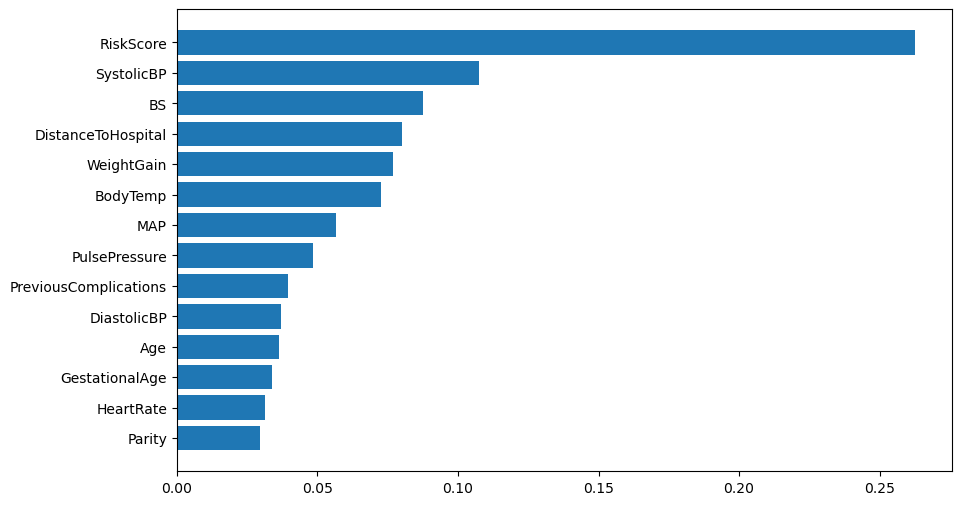

In [70]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance.head(15))

plt.figure(figsize=(10,6))
plt.barh(importance['Feature'][:15], importance['Importance'][:15])
plt.gca().invert_yaxis()
plt.show()

In [71]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

print(comparison)


# The XGBoost classifier achieved the highest prediction accuracy of 89.45%, outperforming the Random Forest model (86.43%). 
# This demonstrates the effectiveness of gradient boosting techniques for maternal health risk prediction.

           Model  Accuracy
0  Random Forest  0.864322
1        XGBoost  0.894472


In [72]:
scores = cross_val_score(xgb,x,y,cv=5,scoring='accuracy')

print(scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())

[0.90452261 0.82828283 0.84343434 0.86868687 0.86363636]
Mean Accuracy: 0.8617126034211461
Std: 0.025832858181164528


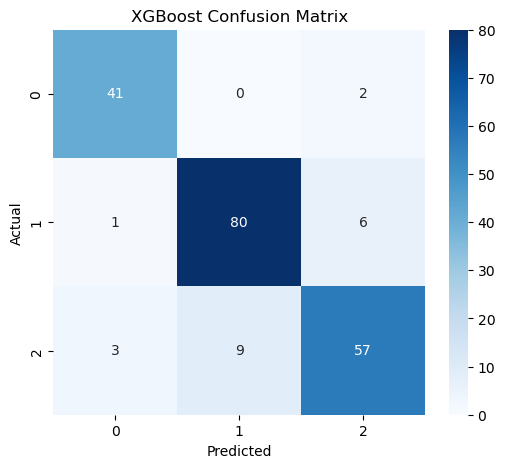

In [73]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

# Logistic Regression

In [74]:
log =LogisticRegression()

In [75]:
log.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [76]:
y_pred_log = log.predict(X_test_scaled)

In [77]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8140703517587939

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        43
           1       0.84      0.92      0.88        87
           2       0.77      0.67      0.71        69

    accuracy                           0.81       199
   macro avg       0.81      0.81      0.81       199
weighted avg       0.81      0.81      0.81       199


Confusion Matrix
[[36  0  7]
 [ 0 80  7]
 [ 8 15 46]]


In [78]:
scores = cross_val_score(log,X_train_scaled,y_train,cv=5,scoring='accuracy')

print(scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())

[0.83018868 0.82389937 0.85443038 0.79746835 0.86708861]
Mean Accuracy: 0.8346150784173234
Std: 0.02433711059510589


# Decision Tree

In [79]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='gini',max_depth=6,min_samples_split=10,min_samples_leaf=5,random_state=42)

In [80]:
dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [81]:
y_pred_dt = dt.predict(X_test)

In [82]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.8140703517587939

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        43
           1       0.86      0.89      0.87        87
           2       0.74      0.71      0.73        69

    accuracy                           0.81       199
   macro avg       0.81      0.81      0.81       199
weighted avg       0.81      0.81      0.81       199


Confusion Matrix
[[36  0  7]
 [ 0 77 10]
 [ 7 13 49]]


# kNN

In [83]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [84]:
y_pred_knn = knn.predict(X_test_scaled)

In [85]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nClassification Report")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_knn))

Accuracy: 0.8241206030150754

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.79      0.84        43
           1       0.81      0.95      0.88        87
           2       0.80      0.68      0.73        69

    accuracy                           0.82       199
   macro avg       0.84      0.81      0.82       199
weighted avg       0.83      0.82      0.82       199


Confusion Matrix
[[34  1  8]
 [ 0 83  4]
 [ 4 18 47]]


# SVM

In [86]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', C=1.0)

In [87]:
svm.fit(X_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [88]:
y_pred_svm = svm.predict(X_test_scaled)

In [89]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.8241206030150754

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        43
           1       0.84      0.93      0.89        87
           2       0.78      0.68      0.73        69

    accuracy                           0.82       199
   macro avg       0.82      0.82      0.82       199
weighted avg       0.82      0.82      0.82       199


Confusion Matrix
[[36  0  7]
 [ 0 81  6]
 [ 7 15 47]]


# ANN

In [90]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [91]:
# Define ANN model
model = Sequential([
    Dense(16, activation='relu', input_shape=(14,)),   
    Dense(8, activation='relu'),                      
    Dense(1, activation='sigmoid')                     
])

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [92]:
# Compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [93]:
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test))
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

Epoch 1/50


25/25 [==============================] - 3s 20ms/step - loss: 0.6681 - accuracy: 0.4053 - val_loss: 0.4555 - val_accuracy: 0.5276
Epoch 2/50
25/25 [==============================] - 0s 5ms/step - loss: 0.3894 - accuracy: 0.4924 - val_loss: 0.2011 - val_accuracy: 0.4975
Epoch 3/50
25/25 [==============================] - 0s 5ms/step - loss: 0.1753 - accuracy: 0.4571 - val_loss: -0.0146 - val_accuracy: 0.4623
Epoch 4/50
25/25 [==============================] - 0s 4ms/step - loss: -0.0168 - accuracy: 0.4444 - val_loss: -0.2143 - val_accuracy: 0.4623
Epoch 5/50
25/25 [==============================] - 0s 5ms/step - loss: -0.2016 - accuracy: 0.4268 - val_loss: -0.4257 - val_accuracy: 0.4573
Epoch 6/50
25/25 [==============================] - 0s 5ms/step - loss: -0.4037 - accuracy: 0.4343 - val_loss: -0.6611 - val_accuracy: 0.4623
Epoch 7/50
25/25 [==============================] - 0s 4ms/step - loss: -0.6383 - accuracy: 0.4621 - val_loss: -0.9433 - val_accuracy: 0.4874
Epoch 8/

In [94]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Final Test Accuracy: {accuracy:.2f}")

7/7 [==============================] - 0s 872us/step - loss: -452.3576 - accuracy: 0.5930
Final Test Accuracy: 0.59


In [95]:
y_pred_ann = model.predict(X_test_scaled)

7/7 [==============================] - 0s 3ms/step


In [96]:
y_pred_ann_classes = (y_pred_ann > 0.5).astype("int32")

In [97]:
mse_ann = mean_squared_error(y_test, y_pred_ann_classes) 


In [98]:
mse_ann

0.4371859296482412

In [99]:
final_data=pd.DataFrame({'Models':['LR','DT','RF','KNN','SVC','XGB','ANN'],"ACC":
                                              [accuracy_score(y_test, y_pred_log)*100,
                                              accuracy_score(y_test, y_pred_dt)*100,
                                              accuracy_score(y_test, y_pred_rf)*100,
                                              accuracy_score(y_test, y_pred_knn)*100,
                                              accuracy_score(y_test, y_pred_svm)*100,
                                              accuracy_score(y_test, y_pred_xgb)*100, 
                                               accuracy*100
                                              ]})

In [100]:
final_data

,Models,ACC
0,LR,81.407035
1,DT,81.407035
2,RF,86.432161
3,KNN,82.412060
4,SVC,82.412060
5,XGB,89.447236
6,ANN,59.296483


In [101]:
# Traditional machine learning algorithms outperformed the Artificial Neural Network due to the relatively small dataset 
# size and tabular nature of the maternal health data. XGBoost achieved the highest accuracy of 89.45%, followed by 
# Random Forest at 86.43%.

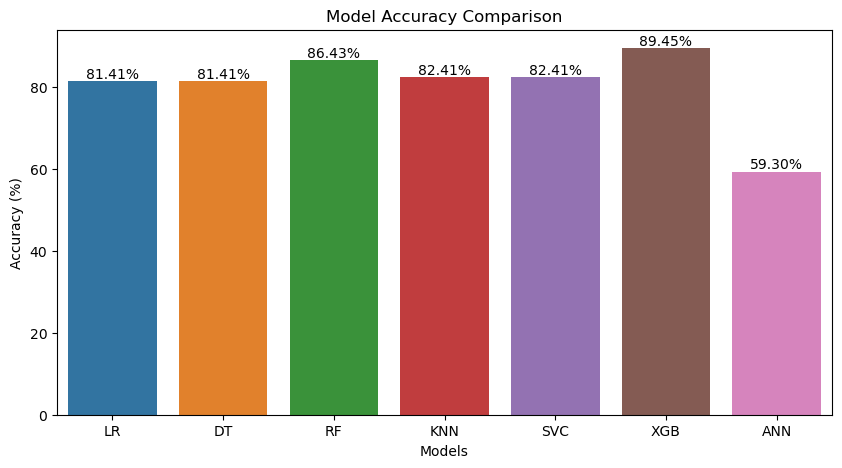

In [102]:
plt.figure(figsize=(10,5))
ax = sns.barplot(data=final_data,
                 x='Models',
                 y='ACC')

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x()+p.get_width()/2,
         p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.show()

In [103]:
Mean_Square_data=pd.DataFrame({'Models':['LR','DT','RF','KNN','SVC','XGB','ANN'],"mse":
                                              [mean_squared_error(y_test, y_pred_log)*100,
                                              mean_squared_error(y_test, y_pred_dt)*100,
                                              mean_squared_error(y_test, y_pred_rf)*100,
                                              mean_squared_error(y_test, y_pred_knn)*100,
                                              mean_squared_error(y_test, y_pred_svm)*100,
                                             mean_squared_error(y_test, y_pred_xgb)*100, 
                                               mse_ann*100
                                              ]})

In [104]:
Mean_Square_data

,Models,mse
0,LR,41.206030
1,DT,39.698492
2,RF,27.135678
3,KNN,35.678392
4,SVC,38.693467
5,XGB,18.090452
6,ANN,43.718593


# gridSearch on RF

In [105]:
# grid Search perform only best two accuracy only

In [106]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [107]:
rf = RandomForestClassifier(random_state=42)

In [108]:
grid_rf = GridSearchCV(rf,param_grid,cv=5,scoring='accuracy',n_jobs=-1)

In [109]:
grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [110]:
print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.8674787039248468


# gridSearch on XGB

In [111]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

In [112]:
xgb = XGBClassifier(objective='multi:softmax',num_class=3,random_state=42)

In [113]:
grid_xgb = GridSearchCV(xgb,param_grid,cv=5,scoring='accuracy',n_jobs=-1)

In [114]:
grid_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=3, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [115]:
print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Score:", grid_xgb.best_score_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score: 0.8636493909720564


In [116]:
# XGBoost achieved the highest predictive performance with a test accuracy of 89.45%, while Random Forest achieved 86.43%. 
# Hyperparameter tuning using GridSearchCV produced marginal improvements, indicating that the baseline models were already
# well-optimized. Based on overall accuracy and robustness, XGBoost was selected as the final model for maternal health risk
# prediction.

In [117]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
from sklearn.model_selection import ( StratifiedKFold,cross_val_score)

In [118]:
# Models Dictionary
models = {
    'Logistic Regression': log,
    'Decision Tree': dt,
    'Random Forest': rf,
    'KNN': knn,
    'SVC': svm,
    'XGBoost': xgb,
    'ANN': model
}

results = []

skf = StratifiedKFold( n_splits=5,shuffle=True,random_state=42)

In [119]:
for name, clf in models.items():

    # ANN handled separately
    if name == 'ANN':

        y_pred_prob = model.predict(X_test_scaled)
        y_pred = y_pred_prob.argmax(axis=1)

        loss, acc = model.evaluate(
            X_test_scaled,
            y_test,
            verbose=0
        )

        results.append({
            'Model': name,
            'Accuracy': round(acc*100,2),
            'Precision': round(precision_score(y_test,y_pred,average='weighted' )*100,2),
            'Recall': round(recall_score(y_test,y_pred,average='weighted')*100,2),
            'F1 Score': round(f1_score(y_test,y_pred,average='weighted')*100,2
            ),
            'CV Mean': 'N/A',
            'CV Std': 'N/A'
        })

    else:

        # Select scaled/unscaled data
        if name in [
            'Logistic Regression',
            'KNN',
            'SVC'
        ]:

            clf.fit(X_train_scaled, y_train)
            y_pred = clf.predict(X_test_scaled)
            cv_scores = cross_val_score(clf,X_scaled,y,cv=skf,scoring='accuracy')

        else:

            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            cv_scores = cross_val_score(clf,x,y,cv=skf,scoring='accuracy')

        results.append({
            'Model': name,
            'Accuracy': round(
                accuracy_score(y_test,y_pred)*100,
                2
            ),
            'Precision': round( precision_score(y_test,y_pred,average='weighted')*100,2),
            'Recall': round(recall_score(y_test,y_pred,average='weighted')*100,2),
            'F1 Score': round(f1_score(y_test,y_pred,average='weighted')*100,2),
            'CV Mean': round(cv_scores.mean()*100,2),
            'CV Std': round(cv_scores.std()*100,2 )
        })

7/7 [==============================] - 0s 6ms/step


In [120]:
# Final Results Table
final_results = pd.DataFrame(results)

final_results = final_results.sort_values(
    by='Accuracy',
    ascending=False
)

print(final_results)

                 Model  Accuracy  Precision  Recall  F1 Score CV Mean CV Std
5              XGBoost     87.44      87.43   87.44     87.43   85.97   1.96
2        Random Forest     86.43      86.30   86.43     86.30   85.57   2.65
3                  KNN     82.41      82.53   82.41     82.00   79.92   2.63
4                  SVC     82.41      82.14   82.41     82.06   82.14   2.67
0  Logistic Regression     81.41      81.08   81.41     81.04   82.14   3.37
1        Decision Tree     81.41      81.24   81.41     81.30   79.82   2.87
6                  ANN     59.30       4.67   21.61      7.68     N/A    N/A


In [121]:
# The Artificial Neural Network underperformed compared to traditional machine learning models due to the limited dataset 
# size and tabular nature of the maternal health dataset.

In [122]:
import pickle

In [123]:
pickle.dump(xgb,open("final_maternal_model.sav",'wb'))

In [124]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("label_encoder.pkl saved successfully!")

label_encoder.pkl saved successfully!


In [125]:
print(le.classes_)

[0 1 2]


In [127]:
print(data[['RiskLevel']].head(20))

    RiskLevel
0           0
1           0
2           0
3           0
4           1
5           0
6           2
7           0
8           2
9           0
10          1
11          2
12          1
13          2
14          2
15          1
16          0
17          0
18          2
19          1


In [128]:
print(y.head(20))

0     0
1     0
2     0
3     0
4     1
5     0
6     2
7     0
8     2
9     0
10    1
11    2
12    1
13    2
14    2
15    1
16    0
17    0
18    2
19    1
Name: RiskLevel, dtype: int32


In [129]:
pd.crosstab(data['RiskLevel'], y)

RiskLevel,0,1,2
RiskLevel,,,
0,263,0,0
1,0,400,0
2,0,0,328
